# Visualize fMRI Distribution: Ground Truth vs Prediction

- **Dataset**: HUWNG (dataset_v7_h)
- **Model**: HierarchicalARM_V3 (hierarchical_v3_1)

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.notebook import tqdm

from model.hierarchical_v3_1 import HierarchicalARM_V3
from data.dataset_v7_h import load_neuroflux_data_v7h

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Configuration

In [18]:
# Configuration
HUWNG_PATH = '../dataset/huwng'
SUBJECTS = [1]  # Available: 1, 2, 5, 7
VOXELS_PER_CLUSTER = 30
CHECKPOINT_PATH = '../checkpoints/_hierarchical_v3.1_subj01_30vpc/best_model.pth'
BATCH_SIZE = 32

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
FIGSIZE = (12, 5)

## Load Dataset

In [19]:
# Load test dataset using dataset_v7_h
test_dataset = load_neuroflux_data_v7h(
    huwng_base_path=HUWNG_PATH,
    subjects=SUBJECTS,
    split='test',
    average_trials=True,  # Average trials for cleaner visualization
    voxels_per_cluster=VOXELS_PER_CLUSTER,
)

print(f"Test samples: {len(test_dataset)}")
print(f"fMRI dim: {test_dataset.fmri_dim}")
print(f"Num ROIs: {test_dataset.num_rois}")

Auto-detected embeddings path: ../dataset/huwng/subj01/nsd_dinov2_vitb14_multilayer_test_sub1.npy
Loading test embeddings from ../dataset/huwng/subj01/nsd_dinov2_vitb14_multilayer_test_sub1.npy...
  Multilayer embeddings detected: (1000, 4, 257, 768)
  Using layer -1 (0-indexed, -1=last)
  Selected shape: (1000, 257, 768)

Processing Subject 1 for test split...
  Loading fMRI from ../dataset/huwng/subj01/nsd_test_fmri_zscore_sub1.npy...
  Loaded shape: (1000, 3, 15724)
  Averaging 3 trials per image...
  After averaging: (1000, 15724)
  Test fMRI: (1000, 15724), 1000 unique images
Using CLS + patches format: (1000, 257, 768)
NeuroFluxDatasetV7H: 1000 samples, 15724 voxels → 524 ROIs (30 voxels/ROI, top-70%) [dtype=float32]
Test samples: 1000
fMRI dim: 15724
Num ROIs: 524


## Load Model

In [20]:
# Load model
model = HierarchicalARM_V3(
    cls_dim=768,
    patch_dim=768,
    num_patches=256,
    fmri_dim=test_dataset.fmri_dim,
    voxels_per_cluster=VOXELS_PER_CLUSTER,
).to(device)

# Load checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
state_dict = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))
model.load_state_dict(state_dict)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded: {n_params:,} parameters")
print(f"Num ROIs: {model.num_rois}")

DualStreamMambaStage1: 15724 voxels → 524 ROIs (30 voxels/ROI, 4 remainder)
Model loaded: 288,016,583 parameters
Num ROIs: 524


## Run Inference

In [21]:
# Collect GT and Predictions
gt_fmri_list = []
pred_fmri_list = []
pred_roi_list = []
gt_roi_list = []

dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4
)

with torch.no_grad():
    for batch in tqdm(dataloader, desc="Running inference"):
        cls_token = batch['cls_token'].to(device)
        patch_tokens = batch['patch_tokens'].to(device)
        gt_fmri = batch['fmri'].numpy()
        gt_roi = batch['roi_means'].numpy()
        
        # Stage 2: Full voxel prediction
        guidance, pred_voxels, _ = model(cls_token, patch_tokens, stage=2)
        
        gt_fmri_list.append(gt_fmri)
        pred_fmri_list.append(pred_voxels.cpu().numpy())
        pred_roi_list.append(guidance.cpu().numpy())
        gt_roi_list.append(gt_roi)

gt_fmri = np.concatenate(gt_fmri_list, axis=0)
pred_fmri = np.concatenate(pred_fmri_list, axis=0)
gt_roi = np.concatenate(gt_roi_list, axis=0)
pred_roi = np.concatenate(pred_roi_list, axis=0)

print(f"GT fMRI: {gt_fmri.shape}")
print(f"Pred fMRI: {pred_fmri.shape}")
print(f"GT ROI: {gt_roi.shape}")
print(f"Pred ROI: {pred_roi.shape}")

Running inference:   0%|          | 0/32 [00:00<?, ?it/s]

GT fMRI: (1000, 15724)
Pred fMRI: (1000, 15724)
GT ROI: (1000, 524)
Pred ROI: (1000, 524)


## Basic Statistics

In [22]:
# Compute basic statistics
def print_stats(name, arr):
    print(f"{name}:")
    print(f"  Mean: {arr.mean():.4f}, Std: {arr.std():.4f}")
    print(f"  Min: {arr.min():.4f}, Max: {arr.max():.4f}")
    print(f"  Median: {np.median(arr):.4f}")
    print()

print("=" * 50)
print("VOXEL-LEVEL STATISTICS")
print("=" * 50)
print_stats("GT fMRI", gt_fmri)
print_stats("Pred fMRI", pred_fmri)

print("=" * 50)
print("ROI-LEVEL STATISTICS")
print("=" * 50)
print_stats("GT ROI", gt_roi)
print_stats("Pred ROI", pred_roi)

VOXEL-LEVEL STATISTICS
GT fMRI:
  Mean: -0.0150, Std: 0.6522
  Min: -3.7496, Max: 3.8521
  Median: -0.0106

Pred fMRI:
  Mean: -0.0161, Std: 0.4356
  Min: -3.5373, Max: 3.3263
  Median: -0.0065

ROI-LEVEL STATISTICS
GT ROI:
  Mean: 0.2619, Std: 0.3216
  Min: -1.5297, Max: 2.1844
  Median: 0.2620

Pred ROI:
  Mean: 0.3808, Std: 0.2907
  Min: -1.3273, Max: 1.9537
  Median: 0.3931



## Distribution Comparison: Histogram

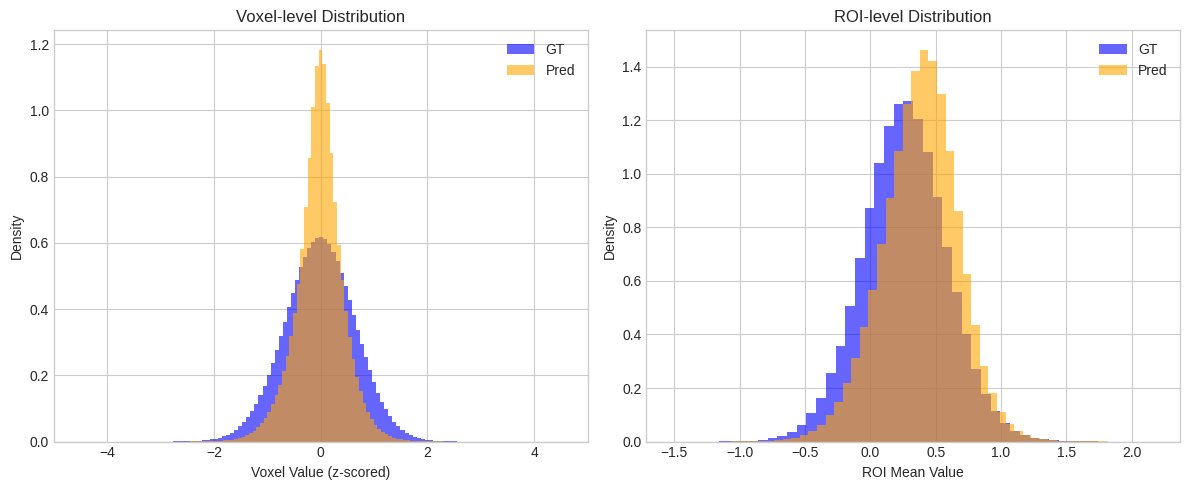

In [23]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Voxel-level histogram
ax = axes[0]
ax.hist(gt_fmri.flatten(), bins=100, alpha=0.6, density=True, label='GT', color='blue')
ax.hist(pred_fmri.flatten(), bins=100, alpha=0.6, density=True, label='Pred', color='orange')
ax.set_xlabel('Voxel Value (z-scored)')
ax.set_ylabel('Density')
ax.set_title('Voxel-level Distribution')
ax.legend()
ax.set_xlim(-5, 5)

# ROI-level histogram
ax = axes[1]
ax.hist(gt_roi.flatten(), bins=50, alpha=0.6, density=True, label='GT', color='blue')
ax.hist(pred_roi.flatten(), bins=50, alpha=0.6, density=True, label='Pred', color='orange')
ax.set_xlabel('ROI Mean Value')
ax.set_ylabel('Density')
ax.set_title('ROI-level Distribution')
ax.legend()

plt.tight_layout()
plt.savefig('../docs/distribution_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

## Scatter Plot: GT vs Pred

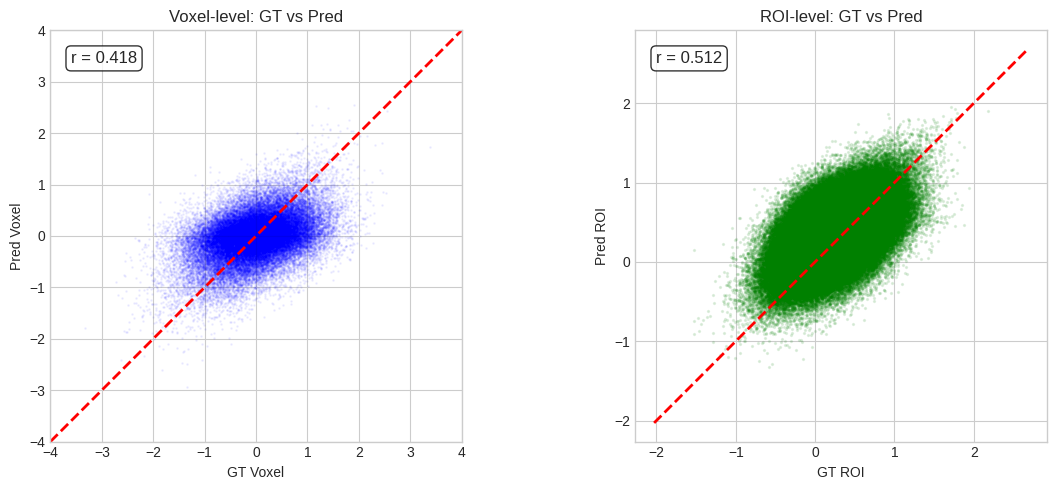

In [24]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Voxel-level scatter (subsample for performance)
n_samples = min(50000, gt_fmri.size)
idx = np.random.choice(gt_fmri.size, n_samples, replace=False)
gt_flat = gt_fmri.flatten()[idx]
pred_flat = pred_fmri.flatten()[idx]

ax = axes[0]
ax.scatter(gt_flat, pred_flat, alpha=0.05, s=1, c='blue')
lims = [-4, 4]
ax.plot(lims, lims, 'r--', linewidth=2, label='y=x')
ax.set_xlabel('GT Voxel')
ax.set_ylabel('Pred Voxel')
ax.set_title('Voxel-level: GT vs Pred')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

# Compute correlation for voxels
r_voxel, _ = stats.pearsonr(gt_flat, pred_flat)
ax.text(0.05, 0.95, f'r = {r_voxel:.3f}', transform=ax.transAxes, 
        fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ROI-level scatter
ax = axes[1]
ax.scatter(gt_roi.flatten(), pred_roi.flatten(), alpha=0.1, s=2, c='green')
lims_roi = [gt_roi.min() - 0.5, gt_roi.max() + 0.5]
ax.plot(lims_roi, lims_roi, 'r--', linewidth=2, label='y=x')
ax.set_xlabel('GT ROI')
ax.set_ylabel('Pred ROI')
ax.set_title('ROI-level: GT vs Pred')
ax.set_aspect('equal')

# Compute correlation for ROIs
r_roi, _ = stats.pearsonr(gt_roi.flatten(), pred_roi.flatten())
ax.text(0.05, 0.95, f'r = {r_roi:.3f}', transform=ax.transAxes,
        fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../docs/distribution_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Sample Correlation

In [25]:
# Compute per-sample correlation
voxel_corrs = []
roi_corrs = []

for i in range(len(gt_fmri)):
    r_v, _ = stats.pearsonr(gt_fmri[i], pred_fmri[i])
    r_r, _ = stats.pearsonr(gt_roi[i], pred_roi[i])
    voxel_corrs.append(r_v)
    roi_corrs.append(r_r)

voxel_corrs = np.array(voxel_corrs)
roi_corrs = np.array(roi_corrs)

print(f"Per-sample Voxel Correlation: {np.mean(voxel_corrs):.4f} ± {np.std(voxel_corrs):.4f}")
print(f"Per-sample ROI Correlation:   {np.mean(roi_corrs):.4f} ± {np.std(roi_corrs):.4f}")

Per-sample Voxel Correlation: 0.4090 ± 0.1232
Per-sample ROI Correlation:   0.5686 ± 0.1720


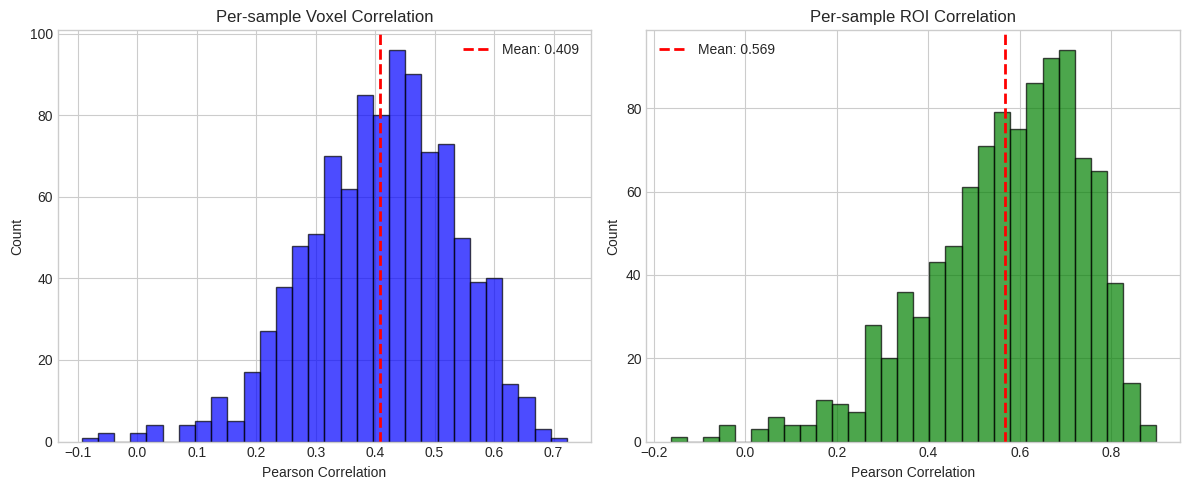

In [26]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Voxel correlation histogram
ax = axes[0]
ax.hist(voxel_corrs, bins=30, alpha=0.7, color='blue', edgecolor='black')
ax.axvline(np.mean(voxel_corrs), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(voxel_corrs):.3f}')
ax.set_xlabel('Pearson Correlation')
ax.set_ylabel('Count')
ax.set_title('Per-sample Voxel Correlation')
ax.legend()

# ROI correlation histogram
ax = axes[1]
ax.hist(roi_corrs, bins=30, alpha=0.7, color='green', edgecolor='black')
ax.axvline(np.mean(roi_corrs), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {np.mean(roi_corrs):.3f}')
ax.set_xlabel('Pearson Correlation')
ax.set_ylabel('Count')
ax.set_title('Per-sample ROI Correlation')
ax.legend()

plt.tight_layout()
plt.savefig('../docs/distribution_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Q-Q Plot

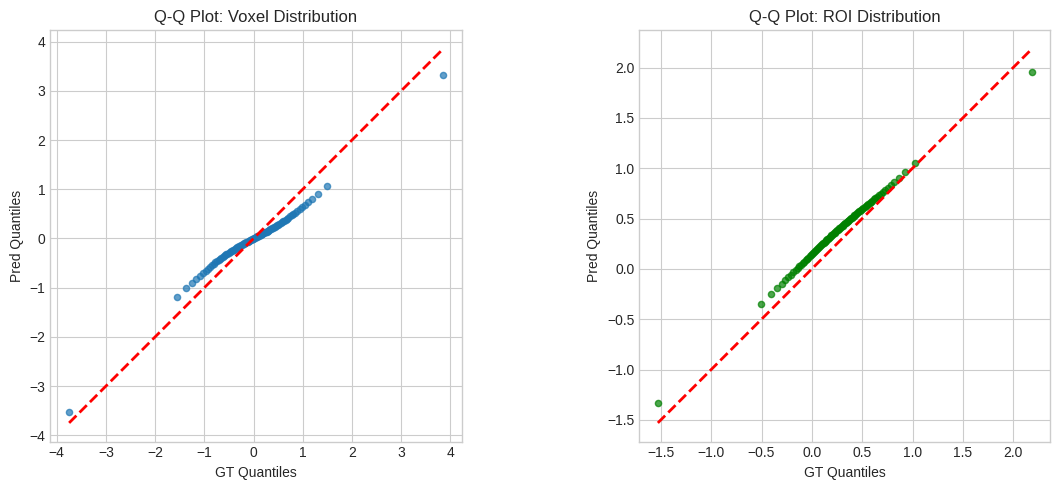

In [27]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Q-Q plot for voxels
ax = axes[0]
gt_quantiles = np.percentile(gt_fmri.flatten(), np.linspace(0, 100, 100))
pred_quantiles = np.percentile(pred_fmri.flatten(), np.linspace(0, 100, 100))
ax.scatter(gt_quantiles, pred_quantiles, alpha=0.7, s=20)
lims = [min(gt_quantiles.min(), pred_quantiles.min()), max(gt_quantiles.max(), pred_quantiles.max())]
ax.plot(lims, lims, 'r--', linewidth=2)
ax.set_xlabel('GT Quantiles')
ax.set_ylabel('Pred Quantiles')
ax.set_title('Q-Q Plot: Voxel Distribution')
ax.set_aspect('equal')

# Q-Q plot for ROIs
ax = axes[1]
gt_q = np.percentile(gt_roi.flatten(), np.linspace(0, 100, 100))
pred_q = np.percentile(pred_roi.flatten(), np.linspace(0, 100, 100))
ax.scatter(gt_q, pred_q, alpha=0.7, s=20, c='green')
lims = [min(gt_q.min(), pred_q.min()), max(gt_q.max(), pred_q.max())]
ax.plot(lims, lims, 'r--', linewidth=2)
ax.set_xlabel('GT Quantiles')
ax.set_ylabel('Pred Quantiles')
ax.set_title('Q-Q Plot: ROI Distribution')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../docs/distribution_qq.png', dpi=150, bbox_inches='tight')
plt.show()

## Sample-wise Visualization

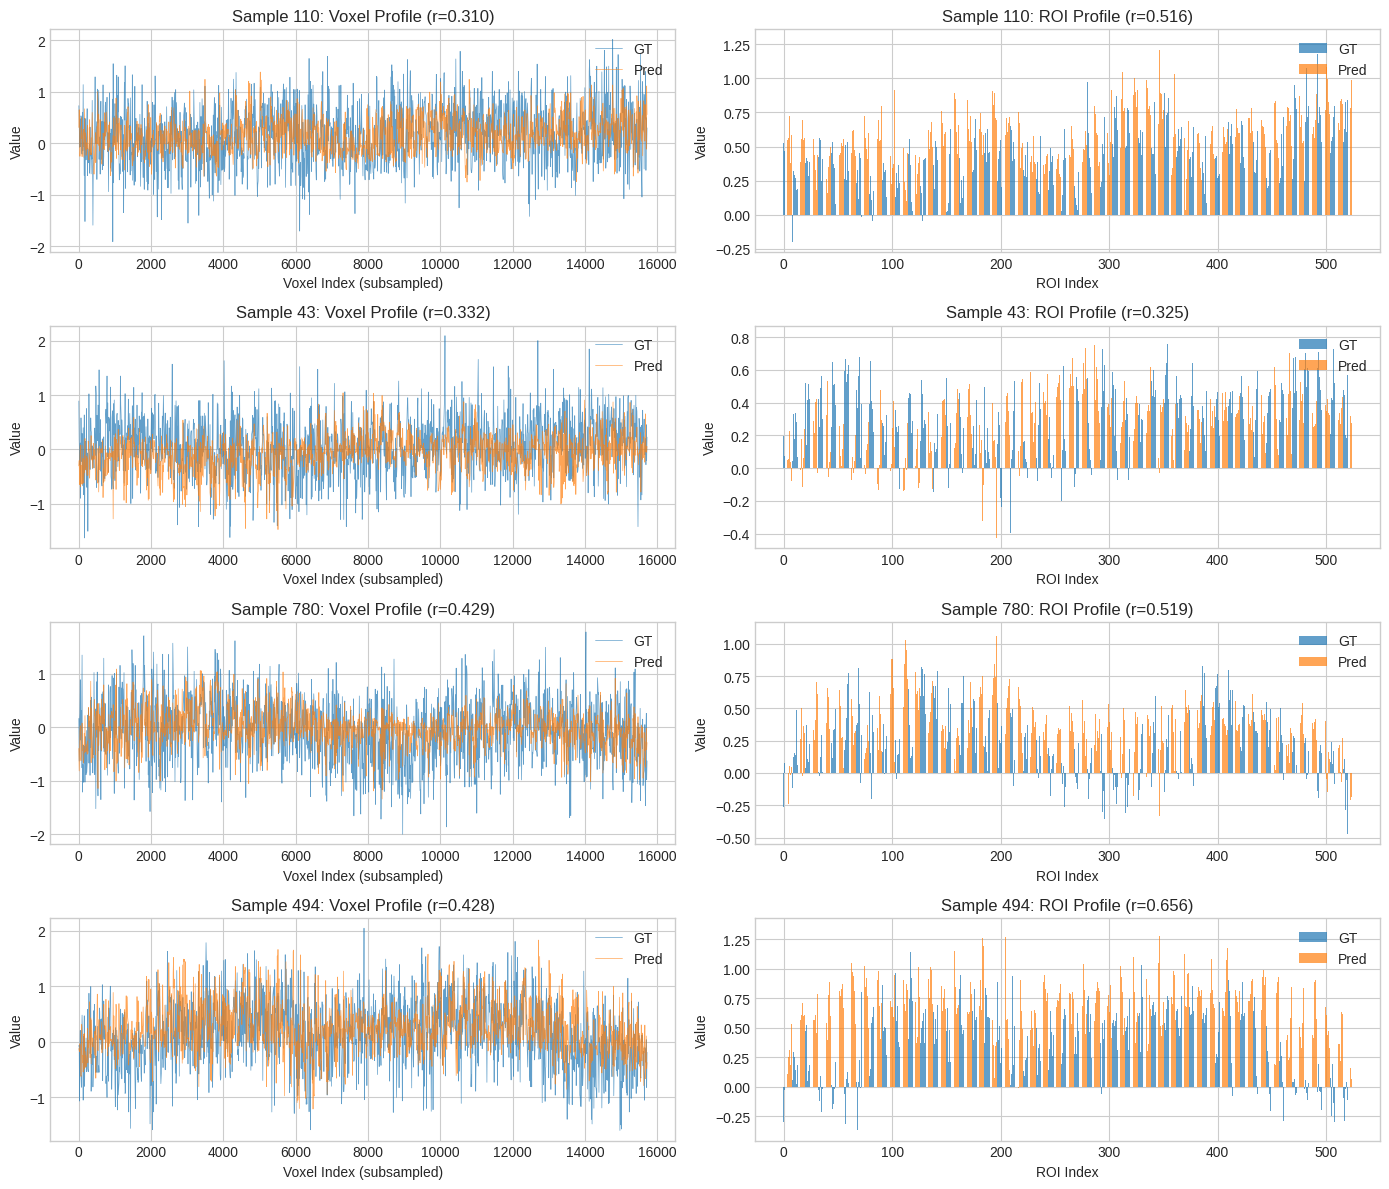

In [28]:
# Visualize a few samples
n_show = 4
sample_indices = np.random.choice(len(gt_fmri), n_show, replace=False)

fig, axes = plt.subplots(n_show, 2, figsize=(14, 3*n_show))

for i, idx in enumerate(sample_indices):
    # Voxel profile
    ax = axes[i, 0]
    x = np.arange(gt_fmri.shape[1])
    ax.plot(x[::10], gt_fmri[idx, ::10], alpha=0.7, label='GT', linewidth=0.5)
    ax.plot(x[::10], pred_fmri[idx, ::10], alpha=0.7, label='Pred', linewidth=0.5)
    r, _ = stats.pearsonr(gt_fmri[idx], pred_fmri[idx])
    ax.set_title(f'Sample {idx}: Voxel Profile (r={r:.3f})')
    ax.set_xlabel('Voxel Index (subsampled)')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right')
    
    # ROI profile
    ax = axes[i, 1]
    x = np.arange(gt_roi.shape[1])
    ax.bar(x - 0.2, gt_roi[idx], width=0.4, alpha=0.7, label='GT')
    ax.bar(x + 0.2, pred_roi[idx], width=0.4, alpha=0.7, label='Pred')
    r, _ = stats.pearsonr(gt_roi[idx], pred_roi[idx])
    ax.set_title(f'Sample {idx}: ROI Profile (r={r:.3f})')
    ax.set_xlabel('ROI Index')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../docs/distribution_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Analysis

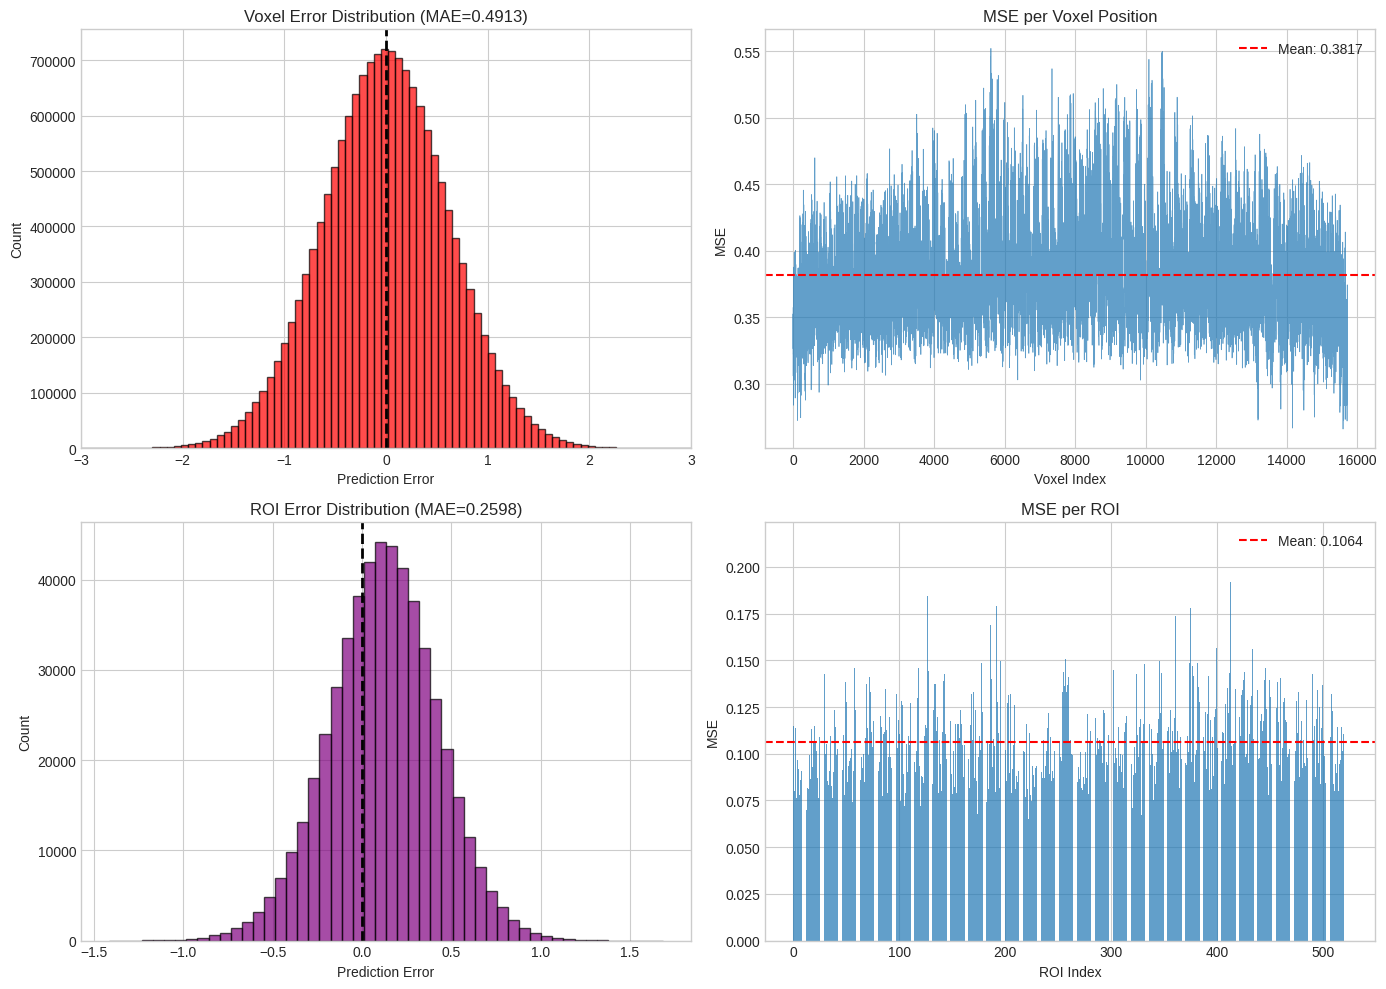

In [29]:
# Compute errors
voxel_error = pred_fmri - gt_fmri
roi_error = pred_roi - gt_roi

# MSE per voxel position
mse_per_voxel = np.mean(voxel_error ** 2, axis=0)
mse_per_roi = np.mean(roi_error ** 2, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Error distribution
ax = axes[0, 0]
ax.hist(voxel_error.flatten(), bins=100, alpha=0.7, color='red', edgecolor='black')
ax.axvline(0, color='black', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Error')
ax.set_ylabel('Count')
ax.set_title(f'Voxel Error Distribution (MAE={np.mean(np.abs(voxel_error)):.4f})')
ax.set_xlim(-3, 3)

# MSE per voxel position
ax = axes[0, 1]
ax.plot(mse_per_voxel, alpha=0.7, linewidth=0.5)
ax.set_xlabel('Voxel Index')
ax.set_ylabel('MSE')
ax.set_title('MSE per Voxel Position')
ax.axhline(np.mean(mse_per_voxel), color='red', linestyle='--', label=f'Mean: {np.mean(mse_per_voxel):.4f}')
ax.legend()

# ROI error distribution
ax = axes[1, 0]
ax.hist(roi_error.flatten(), bins=50, alpha=0.7, color='purple', edgecolor='black')
ax.axvline(0, color='black', linestyle='--', linewidth=2)
ax.set_xlabel('Prediction Error')
ax.set_ylabel('Count')
ax.set_title(f'ROI Error Distribution (MAE={np.mean(np.abs(roi_error)):.4f})')

# MSE per ROI
ax = axes[1, 1]
ax.bar(np.arange(len(mse_per_roi)), mse_per_roi, alpha=0.7)
ax.set_xlabel('ROI Index')
ax.set_ylabel('MSE')
ax.set_title('MSE per ROI')
ax.axhline(np.mean(mse_per_roi), color='red', linestyle='--', label=f'Mean: {np.mean(mse_per_roi):.4f}')
ax.legend()

plt.tight_layout()
plt.savefig('../docs/distribution_error.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [30]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Model: HierarchicalARM_V3 (hierarchical_v3_1)")
print(f"Dataset: HUWNG (dataset_v7_h)")
print(f"Subjects: {SUBJECTS}")
print(f"Test samples: {len(gt_fmri)}")
print(f"Voxels per cluster: {VOXELS_PER_CLUSTER}")
print(f"Num ROIs: {model.num_rois}")
print()
print("Metrics:")
print(f"  Voxel Correlation: {np.mean(voxel_corrs):.4f} ± {np.std(voxel_corrs):.4f}")
print(f"  ROI Correlation:   {np.mean(roi_corrs):.4f} ± {np.std(roi_corrs):.4f}")
print(f"  Voxel MSE:         {np.mean(voxel_error**2):.4f}")
print(f"  ROI MSE:           {np.mean(roi_error**2):.4f}")
print(f"  Voxel MAE:         {np.mean(np.abs(voxel_error)):.4f}")
print(f"  ROI MAE:           {np.mean(np.abs(roi_error)):.4f}")
print("=" * 60)

SUMMARY
Model: HierarchicalARM_V3 (hierarchical_v3_1)
Dataset: HUWNG (dataset_v7_h)
Subjects: [1]
Test samples: 1000
Voxels per cluster: 30
Num ROIs: 524

Metrics:
  Voxel Correlation: 0.4090 ± 0.1232
  ROI Correlation:   0.5686 ± 0.1720
  Voxel MSE:         0.3817
  ROI MSE:           0.1064
  Voxel MAE:         0.4913
  ROI MAE:           0.2598
